# LSTM: re-evaluation

Re-run of `lstm.ipynb` (originally `improving_lstm.ipynb`), the model the real-time system uses.

**Same as the original:** displacement-vector windows reshaped to (25 steps, 50 features); two stacked LSTM layers (64, 64) with Dropout 0.5 / 0.3 and L2, a Dense(16) layer, softmax; Adam (lr 0.001), batch size 15, 20 epochs.

**Different from the original:** the original passed its test set as `validation_data` while it was being tuned, on a dataset that no longer exists. Here training runs a fixed 20 epochs with no validation data, and the model is scored with the shared protocol below.

At the end, one model is trained on all 41 recordings and saved as `models/lstm_reeval.keras`, next to the thesis model in `models/lstm/`. The real-time server still loads `models/lstm/`.

**Evaluation protocol (shared by every `reeval_*` notebook, see `src/reeval_common.py`):**

- Data: `data/keypoint_sequences.csv`, 41 Kinect recordings that survived; the larger folder the thesis notebooks used is lost.
- 6 classes, as in the thesis models: `squat_front` and `squat_side` are merged into `squat`.
- Stratified 5-fold cross-validation over **recordings**, repeated with 3 shuffles (15 splits). All windows of a recording are on the same side of every split.
- Nothing from a test fold is used for training, hyperparameter search or early stopping.
- Reported per split: window accuracy, macro F1, accuracy after a majority vote per recording (what the real-time system does), and a majority-class baseline.
- The spread across splits is shown as ± one standard deviation. Splits share recordings, so this understates the true uncertainty; with 41 recordings, differences of a few points are not meaningful.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "keypoint_sequences.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import reeval_common as rc

records = rc.load_recordings()
table = rc.recordings_table(records)
table.groupby("label").agg(recordings=("rec_id", "count"), frames=("n_frames", "sum"))

,recordings,frames
label,,
bent-over_rows,6,456
biceps,6,456
latheral_raises,6,455
rdl,6,455
shoulder_press,6,456
squat,11,836


In [2]:
X, y, groups = rc.displacement_windows(records)
print("windows:", X.shape, "(windows, steps, keypoints, dx/dy)")
pd.Series(y).value_counts().rename("windows").to_frame()

windows: (121, 25, 25, 2) (windows, steps, keypoints, dx/dy)


,windows
squat,33
bent-over_rows,18
biceps,18
shoulder_press,18
latheral_raises,17
rdl,17


In [3]:
import keras
from keras import layers

print("keras", keras.__version__)


def build_lstm():
    model = keras.Sequential([
        keras.Input(shape=(rc.WINDOW, 50)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.5),
        layers.LSTM(64, kernel_regularizer="l2"),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu", kernel_regularizer="l2", bias_regularizer="l2"),
        layers.Dense(len(rc.CLASSES), activation="softmax"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def fit_predict(X_train, y_train, groups_train, X_test, seed):
    keras.utils.set_random_seed(seed)
    model = build_lstm()
    model.fit(X_train.reshape(len(X_train), rc.WINDOW, -1), rc.one_hot(y_train), batch_size=15, epochs=20, verbose=0)
    proba = model.predict(X_test.reshape(len(X_test), rc.WINDOW, -1), verbose=0)
    return np.array(rc.CLASSES)[proba.argmax(axis=1)]


result = rc.evaluate(
    fit_predict, X, y, groups, rc.recording_splits(groups, records),
    model="LSTM", variant="windows", split="recording-level 5-fold × 3",
    features="displacement windows (25 × 50)", params="LSTM 64-64, Dense 16, Adam 1e-3, batch 15, 20 epochs",
)
result["environment"]["keras"] = keras.__version__
rc.save_results(result, "lstm")
rc.summary_table([result])

keras 3.15.1


,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,LSTM,windows,recording-level 5-fold × 3,121,15,77.3% ± 10.9%,77.6% ± 9.3%,77.3% ± 8.9%,27.1%


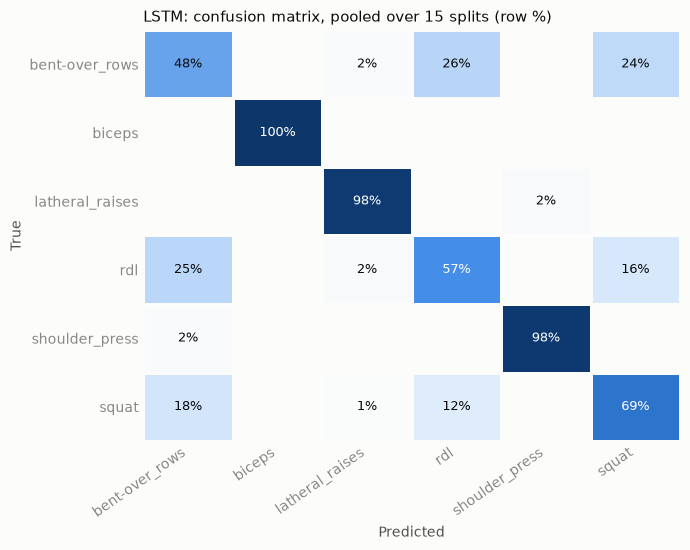

In [4]:
rc.plot_confusion(result, "LSTM: confusion matrix, pooled over 15 splits (row %)", "lstm_confusion.png");

## Final model on all recordings

In [5]:
keras.utils.set_random_seed(0)
final_model = build_lstm()
final_model.fit(X.reshape(len(X), rc.WINDOW, -1), rc.one_hot(y), batch_size=15, epochs=20, verbose=0)
final_path = rc.ROOT / "models" / "lstm_reeval.keras"
final_model.save(final_path)
print("saved", final_path.relative_to(rc.ROOT))

saved models/lstm_reeval.keras
